---

<h1 style="color: #67EBFA; text-align: center;">Prueba Escrita – Arroyo Auz Christian Xavier</h1>
<h1 style="color: #67EBFA; text-align: center;">Laboratorio de Ciencia de Datos</h1>
<h1 style="color: #67EBFA; text-align: center;">Proceso de Selección de un Técnico de Investigación</h1>
<h1 style="color: #67EBFA; text-align: center;">Modelado de Machine Learning</h1>

## Objetivos
El objetivo de esta evaluación es analizar la capacidad del postulante para desarrollar un flujo completo de trabajo en ciencia de datos, desde el procesamiento de datos hasta el despliegue de un modelo como servicio.

Se evaluarán competencias en:
* Procesamiento y análisis de datos
* Modelado de Machine Learning
* Desarrollo de software
* Despliegue de servicios (API)
* Documentación y reproducibilidad

---

<h1 style="color: #9BFBE1; text-align: center;"><strong>EJECUCIÓN DE LA PRUEBA</strong></h1>

## DataSet a Utilizar (real_state_ecuador_dataset.csv)

Este conjunto de datos proporciona una descripción general completa de las propiedades de alquiler en Ecuador. Contiene una gran cantidad de información sobre las propiedades, como sus títulos y ubicaciones, así como el número de dormitorios, baños y garajes que contienen. Además, también incluye puntos de datos valiosos, como el tamaño del área, para ayudar a tomar decisiones informadas para quienes buscan alquilar o arrendar propiedades dentro del país. Los datos se pueden utilizar por diversas razones, como analizar tendencias en propiedades ofrecidas en alquiler y buscar diferencias de precios entre regiones o localidades.

Puedes descargar este dataset desde el siguiente [enlace](https://github.com/ivan-carrera/adalab-persel/blob/main/data/archive.zip).

## Descripción de las Variables del DataSet

A continuación se describe cada una de las columnas presentes en el dataset de propiedades en alquiler en Ecuador:

### 1. **Titulo**
- **Tipo:** Texto (string)
- **Descripción:** Contiene el título o descripción breve de la publicación del inmueble. Incluye características como el tipo de propiedad (departamento, casa, suite, local comercial, etc.), ubicación general, y en muchos casos, palabras clave como "oportunidad", "amoblado", o "estreno".
- **Ejemplo:** `"Hermoso departamento de arriendo sector iñaquito"`

### 2. **Precio**
- **Tipo:** Numérico (entero o decimal)
- **Descripción:** Indica el valor mensual del alquiler en dólares estadounidenses (USD). En algunos casos, puede incluir valores atípicos que corresponden a ventas o terrenos.
- **Ejemplo:** `500`, `375`, `650`

### 3. **Provincia**
- **Tipo:** Texto (string)
- **Descripción:** Provincia de Ecuador donde se encuentra el inmueble. La mayoría de los registros corresponden a **Pichincha**, aunque también aparecen otras como Guayas, Manabí, Imbabura, etc.
- **Ejemplo:** `"Pichincha"`, `"Guayas"`, `"Manabí"`

### 4. **Lugar**
- **Tipo:** Texto (string)
- **Descripción:** Descripción detallada de la ubicación del inmueble. Incluye provincia, ciudad, parroquia, sector, direcciones específicas y, en ocasiones, referencias geográficas o comerciales.
- **Ejemplo:** `"Pichincha, Iñaquito, Quito, Ecuador"`

### 5. **Num. dormitorios**
- **Tipo:** Numérico (entero) o `NaN`
- **Descripción:** Número de habitaciones o dormitorios que tiene la propiedad. Puede ser `NaN` en propiedades comerciales, terrenos, oficinas o locales sin dormitorios.
- **Ejemplo:** `2`, `3`, `1`, `NaN`

### 6. **Num. banos**
- **Tipo:** Numérico (entero o decimal) o `NaN`
- **Descripción:** Número de baños que tiene la propiedad. En algunos casos puede incluir medios baños (ej. `2.5`). Puede ser `NaN` si no aplica o no se especifica.
- **Ejemplo:** `2`, `1`, `3`, `NaN`, `2.5`

### 7. **Area**
- **Tipo:** Numérico (entero o decimal) o `NaN`
- **Descripción:** Superficie total del inmueble en metros cuadrados (m²). Puede incluir áreas construidas o del terreno. En algunos registros aparece como `NaN` si no se especifica.
- **Ejemplo:** `95`, `240`, `90`, `NaN`

### 8. **Num. garages**
- **Tipo:** Numérico (entero) o `NaN`
- **Descripción:** Número de espacios de estacionamiento o garajes disponibles en la propiedad. Puede ser `0` o `NaN` si no tiene o no se especifica.
- **Ejemplo:** `1`, `2`, `0`, `NaN`

### Resumen general del dataset

- **Enfoque:** Publicaciones de alquiler de inmuebles en Ecuador, principalmente en la provincia de Pichincha (Quito y sus alrededores).
- **Tipos de propiedades:** Departamentos, casas, suites, locales comerciales, oficinas, bodegas, terrenos, entre otros.
- **Variables clave:** Precio, ubicación, número de habitaciones, baños, área y garajes.
- **Datos faltantes:** Algunas variables como `Num. dormitorios`, `Num. banos`, `Area` y `Num. garages` presentan valores `NaN`, especialmente en propiedades no residenciales.

## Instalación de Librerías

```python
# Instalación de librerías necesarias para el análisis de datos
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install joblib
!pip install pandas
!pip install numpy

## Importar Librerías

In [1]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV      # Para dividir datos, validación cruzada y búsqueda de hiperparámetros
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler            # Para codificar variables y escalar datos
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor            # Modelos de ensamble (Random Forest y Gradient Boosting)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score            # Métricas para evaluar modelos de regresión
from sklearn.compose import ColumnTransformer                                            # Para aplicar transformaciones diferentes a columnas específicas
from sklearn.linear_model import Ridge, Lasso                                            # Modelos de regresión lineal con regularización
from IPython.display import display, Markdown                                            # Para mostrar encabezado en los dataframe
from sklearn.pipeline import Pipeline                                                    # Para crear flujos de trabajo secuenciales
import matplotlib.pyplot as plt                                                          # Para crear gráficos y visualizaciones
import seaborn as sns                                                                    # Para visualizaciones estadísticas más atractivas
import pandas as pd                                                                      # Para manipulación y análisis de datos (DataFrames)
import numpy as np                                                                       # Para operaciones numéricas y arreglos multidimensionales
import warnings                                                                          # Control de advertencias durante la ejecución
import joblib                                                                            # Para guardar y cargar modelos entrenados

## Carga del DataSet

In [2]:
# Configuración de visualización
plt.style.use('seaborn-v0_8')                  # Configuración de estilo para gráficos
sns.set_palette("husl")                        # Establece paleta de colores vibrantes y uniformes
pd.set_option('display.max_columns', None)     # Muestra TODAS las columnas de DataFrames sin truncar

# Cargar el dataset
df = pd.read_csv('../data/real_state_ecuador_dataset.csv')
df.head(10)

,Titulo,Precio,Provincia,Lugar,Num. dormitorios,Num. banos,Area,Num. garages
0,Hermoso departamento de arriendo sector iñaquito,500,Pichincha,"Pichincha, Iñaquito, Quito, Ecuador",2,2.0,95.0,1.0
1,Hermosa suite de arriendo sector iñaquito,375,Pichincha,"Pichincha, Quito, Ecuador",1,1.0,65.0,1.0
2,Hermoso departamento de oportunidad de arriend...,650,Pichincha,"Pichincha, Av. República de El Salvador, Quito...",2,2.0,120.0,1.0
3,Hermoso departamento de arriendo de 240 metros...,560,Pichincha,"Pichincha, Albert Einstein, Quito, Ecuador",3,3.0,240.0,2.0
4,Hermoso departamento de arriendo de oportunida...,580,Pichincha,"Pichincha, Urbanización El Condado, Calle C, Q...",3,4.0,128.0,2.0
5,Hermosa suite de arriendo de oportunidad secto...,460,Pichincha,"Pichincha, Quito Tenis, Quito, Ecuador",1,1.0,58.0,1.0
6,Hermoso departamento en renta sector Quito Tenis,435,Pichincha,"Pichincha, Quito Tenis, Quito 170104, Ecuador",2,2.0,98.0,1.0
7,Hermoso departamento de arriendo en la Urb. El...,750,Pichincha,"Pichincha, VGW2+Q5J, Quito 170134, Ecuador",3,3.0,190.0,1.0
8,Hermosa suite amoblada de arriendo sector Quit...,570,Pichincha,"Pichincha, Quito Tenis, Quito 170104, Ecuador",1,1.0,61.0,1.0
9,Hermoso departamento en renta/venta sector Qui...,1800,Pichincha,"Pichincha, Quito Tenis, Quito 170104, Ecuador",4,3.0,380.0,3.0


## Limpieza y Normalización

In [3]:
# Función para extraer información relevante de Lugar
def extract_location_info(lugar_str):
    """
    Extrae ciudad y sector de la columna Lugar
    Ejemplo: "Pichincha, Iñaquito, Quito, Ecuador" -> {"ciudad": "Quito", "sector": "Iñaquito"}
    """
    # Si el valor es nulo, devolvemos una Serie con None
    if pd.isna(lugar_str):
        return pd.Series({'ciudad': None, 'sector': None})
    
    # Dividimos la cadena por comas y limpiamos espacios
    partes = lugar_str.split(',')
    partes = [p.strip() for p in partes]
    
    # Inicializamos las variables a None
    ciudad_encontrada = None  # <--- Variable inicializada aquí
    sector = None
    
    # Lista de ciudades conocidas para buscar en el texto
    ciudades_conocidas = ['Quito', 'Guayaquil', 'Cuenca', 'Sangolquí', 'Cumbayá', 
                          'Tumbaco', 'Machala', 'Manta', 'Babahoyo', 'Latacunga']
    
    # Buscamos si alguna parte coincide con una ciudad conocida
    for parte in partes:
        for ciudad in ciudades_conocidas:
            if ciudad.lower() in parte.lower():
                ciudad_encontrada = ciudad
                break   # Rompemos el bucle interno
        if ciudad_encontrada:  # Si ya encontramos ciudad, rompemos el bucle externo
            break
    
    # Si encontramos una ciudad, el sector suele estar justo antes
    if ciudad_encontrada:
        # Obtenemos el índice de la parte que contiene la ciudad
        for i, parte in enumerate(partes):
            if ciudad_encontrada.lower() in parte.lower():
                idx_ciudad = i
                break
        
        # Si la ciudad no es el primer elemento, el anterior es el sector
        if idx_ciudad > 0:
            sector = partes[idx_ciudad - 1]
    
    # Devolvemos los resultados como una Serie de pandas
    return pd.Series({'ciudad': ciudad_encontrada, 'sector': sector})

In [4]:
# Aplicar la función extract_location_info a cada valor de la columna 'Lugar'
# La función devuelve una Serie con dos valores: 'ciudad' y 'sector'
# Luego asignamos esos dos valores a dos nuevas columnas en el DataFrame: 'ciudad' y 'sector'
df[['ciudad', 'sector']] = df['Lugar'].apply(extract_location_info)

# Normalizar nombres de provincias:
# .str.strip()  -> Elimina espacios en blanco al inicio y final de cada texto
# .str.title()  -> Convierte la primera letra de cada palabra a mayúscula y el resto a minúsculas
# Ejemplo: "pICHINCHA" -> "Pichincha"
df['Provincia'] = df['Provincia'].str.strip().str.title()
df.head(10)

,Titulo,Precio,Provincia,Lugar,Num. dormitorios,Num. banos,Area,Num. garages,ciudad,sector
0,Hermoso departamento de arriendo sector iñaquito,500,Pichincha,"Pichincha, Iñaquito, Quito, Ecuador",2,2.0,95.0,1.0,Quito,Pichincha
1,Hermosa suite de arriendo sector iñaquito,375,Pichincha,"Pichincha, Quito, Ecuador",1,1.0,65.0,1.0,Quito,Pichincha
2,Hermoso departamento de oportunidad de arriend...,650,Pichincha,"Pichincha, Av. República de El Salvador, Quito...",2,2.0,120.0,1.0,Quito,Av. República de El Salvador
3,Hermoso departamento de arriendo de 240 metros...,560,Pichincha,"Pichincha, Albert Einstein, Quito, Ecuador",3,3.0,240.0,2.0,Quito,Albert Einstein
4,Hermoso departamento de arriendo de oportunida...,580,Pichincha,"Pichincha, Urbanización El Condado, Calle C, Q...",3,4.0,128.0,2.0,Quito,Calle C
5,Hermosa suite de arriendo de oportunidad secto...,460,Pichincha,"Pichincha, Quito Tenis, Quito, Ecuador",1,1.0,58.0,1.0,Quito,Pichincha
6,Hermoso departamento en renta sector Quito Tenis,435,Pichincha,"Pichincha, Quito Tenis, Quito 170104, Ecuador",2,2.0,98.0,1.0,Quito,Pichincha
7,Hermoso departamento de arriendo en la Urb. El...,750,Pichincha,"Pichincha, VGW2+Q5J, Quito 170134, Ecuador",3,3.0,190.0,1.0,Quito,VGW2+Q5J
8,Hermosa suite amoblada de arriendo sector Quit...,570,Pichincha,"Pichincha, Quito Tenis, Quito 170104, Ecuador",1,1.0,61.0,1.0,Quito,Pichincha
9,Hermoso departamento en renta/venta sector Qui...,1800,Pichincha,"Pichincha, Quito Tenis, Quito 170104, Ecuador",4,3.0,380.0,3.0,Quito,Pichincha


## Manejo de Valores Faltantes

In [5]:
# Análisis de valores faltantes
# .isnull().sum() cuenta cuántos valores nulos hay en cada columna
missing_values = df.isnull().sum()

# Calculamos el porcentaje de valores faltantes
missing_percentage = (missing_values / len(df)) * 100

# Creamos un DataFrame con la información de valores faltantes
missing_df = pd.DataFrame({'Missing': missing_values, 'Percentage': missing_percentage})

# Mostramos solo las columnas que tienen al menos un valor faltante
# Ordenamos de mayor a menor cantidad de valores faltantes
print(missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False))

                  Missing  Percentage
Num. garages          152        30.4
Num. dormitorios      140        28.0
Num. banos             97        19.4
ciudad                 51        10.2
sector                 51        10.2
Area                   18         3.6


In [6]:
# Estrategias de imputación (rellenar valores faltantes)
# Para columnas numéricas: usar la mediana
warnings.simplefilter("ignore")
# Lista de columnas numéricas (¡verifica que los nombres coincidan exactamente con el CSV!)
numeric_cols = ['Num. dormitorios', 'Num. banos', 'Area', 'Num. garages']

# Procesamos cada columna numérica
for col in numeric_cols:
    # Convertimos la columna a tipo numérico (si hay errores, los convierte a NaN)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Rellenamos los valores NaN con la mediana de la columna
    # fillna() reemplaza NaN con el valor especificado
    # inplace=True modifica el DataFrame directamente
    df[col].fillna(df[col].median(), inplace=True)

# Para categóricos: crear categoría 'Desconocido'
df['ciudad'].fillna('Desconocido', inplace=True)
df['sector'].fillna('Desconocido', inplace=True)

# Verificar que no queden nulos
print(df.isnull().sum())

Titulo              0
Precio              0
Provincia           0
Lugar               0
Num. dormitorios    0
Num. banos          0
Area                0
Num. garages        0
ciudad              0
sector              0
dtype: int64


## Seleccionar Características para el Modelo

In [7]:
# Definir las columnas que usaremos como características (variables predictoras)
features = ['Provincia', 'ciudad', 'sector', 'Num. dormitorios', 'Num. banos', 'Area', 'Num. garages']
# Definir la columna que queremos predecir (variable objetivo)
target = 'Precio'

# ============================================================
# ELIMINACIÓN DE OUTLIERS (VALORES ATÍPICOS)
# ============================================================

# Calcular el primer cuartil (Q1) - valor por debajo del cual está el 25% de los datos
Q1 = df[target].quantile(0.25)
# Calcular el tercer cuartil (Q3) - valor por debajo del cual está el 75% de los datos
Q3 = df[target].quantile(0.75)
# Calcular el rango intercuartílico (IQR) - medida de dispersión estadística
IQR = Q3 - Q1

# Definir límites para detectar outliers usando el método del rango intercuartílico
lower_bound = Q1 - 1.5 * IQR  # Límite inferior: valores menores a esto son outliers
upper_bound = Q3 + 1.5 * IQR  # Límite superior: valores mayores a esto son outliers

# Filtrar el DataFrame para quedarnos solo con valores dentro de los límites (no outliers)
df_clean = df[(df[target] >= lower_bound) & (df[target] <= upper_bound)]

# Mostrar cuántos datos eliminamos
print(f"Filas originales: {len(df)}, después de eliminar outliers: {len(df_clean)}")

# ============================================================
# PREPARACIÓN DE DATOS PARA MODELADO
# ============================================================

# Separar el dataset en características (X) y variable objetivo (y)
X = df_clean[features]  # Matriz de características (variables predictoras)
y = df_clean[target]    # Vector objetivo (lo que queremos predecir)

# ============================================================
# DIVISIÓN EN CONJUNTOS DE ENTRENAMIENTO Y PRUEBA
# ============================================================

# Dividir los datos en 80% para entrenamiento y 20% para prueba
# random_state=42 asegura que la división sea reproducible (siempre igual)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostrar las dimensiones de los conjuntos de datos resultantes
print(f"Entrenamiento: {X_train.shape}, Prueba: {X_test.shape}")

Filas originales: 500, después de eliminar outliers: 446
Entrenamiento: (356, 7), Prueba: (90, 7)


In [8]:
display(Markdown("##### Datos de Entrenamiento"))
X_train.head(10)

##### Datos de Entrenamiento

,Provincia,ciudad,sector,Num. dormitorios,Num. banos,Area,Num. garages
18,Pichincha,Quito,Ponceano Alto,4.0,3.0,130.0,2.0
77,Pichincha,Quito,La Pampa,3.0,2.0,137.0,2.0
204,Pichincha,Quito,Ponceano Alto,3.0,2.0,120.0,1.0
284,Pichincha,Quito,Cotocollao,3.0,1.0,80.0,1.0
34,Pichincha,Quito,Comité del Pueblo,3.0,1.0,80.0,1.0
95,Pichincha,Quito,El Bosque,1.0,2.0,70.0,1.0
346,Pichincha,Quito,Los Laureles,3.0,3.0,100.0,1.0
393,Pichincha,Quito,De los Guayacanes,3.0,3.0,160.0,2.0
209,Pichincha,Quito,Yaruquí,3.0,2.0,180.0,1.0
321,Pichincha,Quito,Avenida República de El Salvador,2.0,2.0,120.0,1.0


In [9]:
display(Markdown("##### Datos de Testeo"))
X_test.head(10)

##### Datos de Testeo

,Provincia,ciudad,sector,Num. dormitorios,Num. banos,Area,Num. garages
324,Pichincha,Quito,De Los Cedros,3.0,2.0,224.0,1.0
400,Pichincha,Quito,Avenida de los Shyris,2.0,3.0,110.0,2.0
134,Pichincha,Cumbayá,Av. Interoceánica 1/2,3.0,3.0,222.0,2.0
471,Pichincha,Quito,El Batán,3.0,2.5,115.0,2.0
81,Pichincha,Quito,Avenida Puruhaes,3.0,2.0,324.0,1.0
33,Pichincha,Quito,Diego de Almagro,1.0,2.0,51.0,1.0
220,Pichincha,Sangolquí,Avenida General Rumiñahui,3.0,2.0,162.0,1.0
90,Pichincha,Quito,Humberto Albornoz,3.0,1.0,90.0,1.0
403,Guayas,Guayaquil,6º Pasaje 9 NO,1.0,1.0,24.0,0.0
378,Pichincha,Quito,Av. Portugal & Av República de El Salvador,1.0,2.0,75.0,1.0


## Crear Pipeline de Preprocesamiento

In [10]:
# Identificar columnas por tipo
# Categóricas: Variables que contienen texto o categorías (ej: "Quito", "Guayaquil")
# Numéricas: Variables con números que representan cantidades
categorical_cols = ['Provincia', 'ciudad', 'sector']
numeric_cols = ['Num. dormitorios', 'Num. banos', 'Area', 'Num. garages']

# Preprocesamiento para variables categóricas
# OneHotEncoder: Convierte categorías en columnas binarias (0/1)
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Preprocesamiento para variables numéricas
# StandardScaler: Estandariza los datos (media=0, desviación estándar=1)
numeric_transformer = StandardScaler()

# Combinar preprocesadores
# ColumnTransformer: Aplica diferentes transformaciones a diferentes columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

## Probar Diferentes Modelos


                       RESULTADOS DE MODELOS DE REGRESIÓN                       

           Modelo      MAE     RMSE     R²  R²_ajustado  CV_R²_mean  CV_R²_std  MAPE (%)
Gradient Boosting 136.8774 176.3175 0.4452       0.3978      0.1873     0.1829   30.5293
    Random Forest 136.5809 183.2939 0.4004       0.3492      0.0865     0.2719   25.3011
            Ridge 165.0924 210.4469 0.2096       0.1421    -18.0548    35.8782   37.2713
            Lasso 167.3929 211.9983 0.1979       0.1294   -104.5457   208.7542   37.5609

🏆 MEJOR MODELO: Gradient Boosting
   R²: 0.4452
   RMSE: 176.3175
   MAE: 136.8774
   MAPE: 30.53%


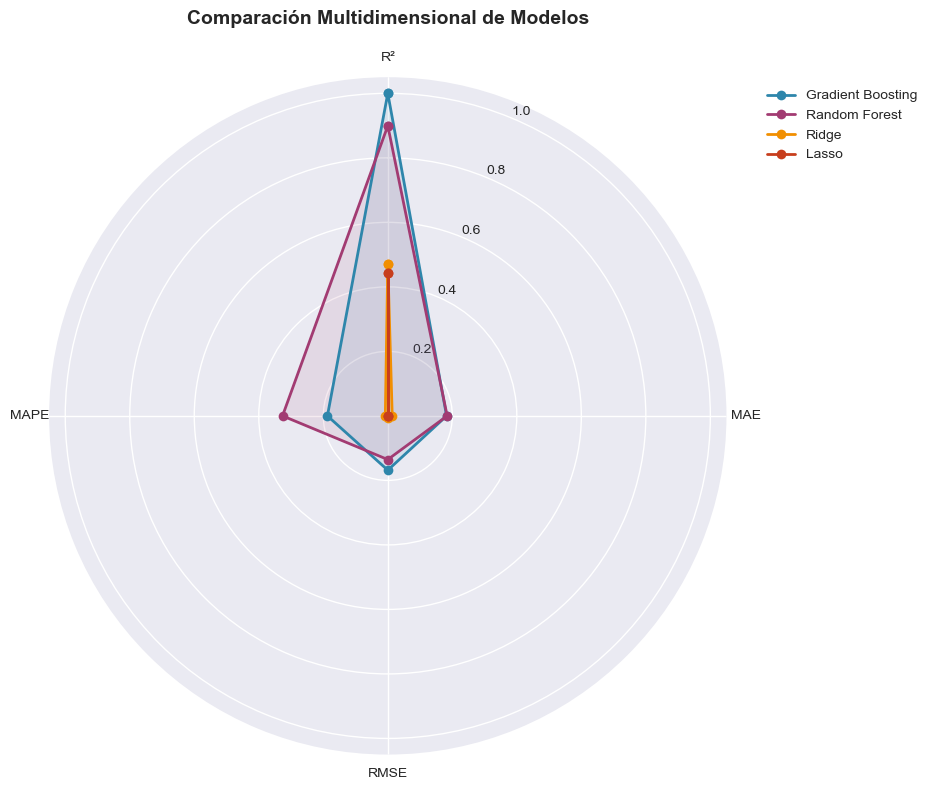

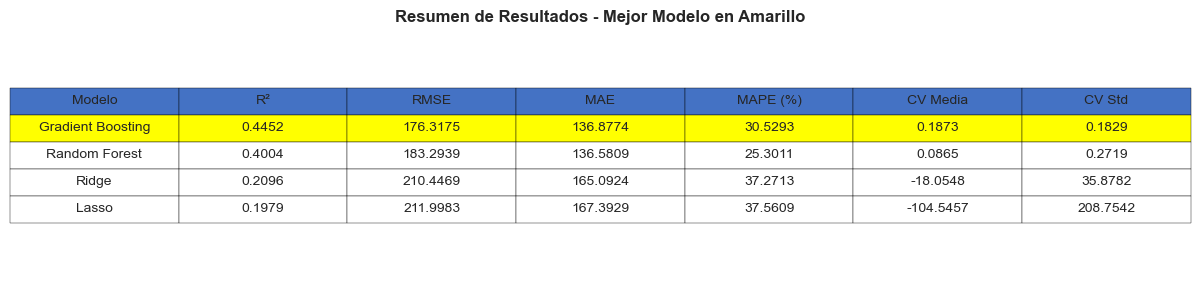


                           ANÁLISIS Y RECOMENDACIONES                           

📊 RANKING POR MÉTRICAS:
----------------------------------------
Por R²: Gradient Boosting > Random Forest > Ridge
Por RMSE: Gradient Boosting (menor error)
Por estabilidad (CV): Gradient Boosting (menor variabilidad)

⚖️ ANÁLISIS DE COMPENSACIONES:
----------------------------------------
• Ridge/Lasso: Mejor interpretabilidad pero menor rendimiento
• Random Forest: Buen balance precisión-estabilidad
• Gradient Boosting: Alto rendimiento pero puede sobreajustar

🎯 RECOMENDACIÓN FINAL:
----------------------------------------
Basado en el análisis completo, se recomienda:
1. Modelo principal: Gradient Boosting (mejor R²: 0.4452)
2. Alternativa robusta: Gradient Boosting (más estable)
3. Para interpretabilidad: Usar Ridge o Lasso



In [11]:
# DICCIONARIO DE MODELOS A EVALUAR
# ---------------------------------
models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# CONFIGURACIÓN DE ESTILO PARA GRÁFICOS
# --------------------------------------
plt.style.use('seaborn-v0_8-darkgrid')  # Estilo moderno
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']  # Paleta de colores profesional

# EVALUACIÓN SISTEMÁTICA DE MODELOS
# ---------------------------------
results = []

for name, model in models.items():
    # Pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])
    
    # Entrenamiento
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Métricas principales
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Validación cruzada
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    
    # Almacenar resultados
    results.append({
        'Modelo': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'R²_ajustado': 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1),
        'CV_R²_mean': cv_scores.mean(),
        'CV_R²_std': cv_scores.std(),
        'MAPE (%)': np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # Error porcentual
    })

# PRESENTACIÓN DE RESULTADOS
# --------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R²', ascending=False)

print("\n" + "="*80)
print("RESULTADOS DE MODELOS DE REGRESIÓN".center(80))
print("="*80)
print("\n" + results_df.to_string(index=False, float_format=lambda x: '{:.4f}'.format(x)))
print("="*80)

# IDENTIFICAR MEJOR MODELO
# ------------------------
best_model = results_df.iloc[0]
print(f"\n🏆 MEJOR MODELO: {best_model['Modelo']}")
print(f"   R²: {best_model['R²']:.4f}")
print(f"   RMSE: {best_model['RMSE']:.4f}")
print(f"   MAE: {best_model['MAE']:.4f}")
print(f"   MAPE: {best_model['MAPE (%)']:.2f}%")

# VISUALIZACIÓN 1: COMPARACIÓN PRINCIPAL
# --------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis Comparativo de Modelos de Regresión', fontsize=16, fontweight='bold')

# Gráfico 1: R² y R² Ajustado (barras)
ax1 = axes[0, 0]
x = np.arange(len(results_df))
width = 0.35

bars1 = ax1.bar(x - width/2, results_df['R²'], width, label='R²', color=colors[0], alpha=0.8)
bars2 = ax1.bar(x + width/2, results_df['R²_ajustado'], width, label='R² Ajustado', color=colors[1], alpha=0.8)

ax1.set_xlabel('Modelo', fontsize=11)
ax1.set_ylabel('R²', fontsize=11)
ax1.set_title('Comparación de R² y R² Ajustado', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['Modelo'], rotation=45, ha='right')
ax1.legend(loc='lower right')
ax1.set_ylim(0, 1)
ax1.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

# Añadir valores en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Gráfico 2: Errores (MAE, RMSE)
ax2 = axes[0, 1]
bars3 = ax2.bar(x - width/2, results_df['MAE'], width, label='MAE', color=colors[2], alpha=0.8)
bars4 = ax2.bar(x + width/2, results_df['RMSE'], width, label='RMSE', color=colors[3], alpha=0.8)

ax2.set_xlabel('Modelo', fontsize=11)
ax2.set_ylabel('Error', fontsize=11)
ax2.set_title('Comparación de Errores (MAE vs RMSE)', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(results_df['Modelo'], rotation=45, ha='right')
ax2.legend(loc='upper right')

# Añadir valores en las barras
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Gráfico 3: Validación Cruzada
ax3 = axes[1, 0]
y_pos = np.arange(len(results_df))
bars5 = ax3.barh(y_pos, results_df['CV_R²_mean'], xerr=results_df['CV_R²_std'],
                 color=colors[0], alpha=0.8, capsize=5)

ax3.set_xlabel('R² en Validación Cruzada', fontsize=11)
ax3.set_ylabel('Modelo', fontsize=11)
ax3.set_title('Validación Cruzada (media ± std)', fontsize=12, fontweight='bold')
ax3.set_yticks(y_pos)
ax3.set_yticklabels(results_df['Modelo'])
ax3.set_xlim(0, 1)
ax3.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)

# Añadir valores
for i, (v, std) in enumerate(zip(results_df['CV_R²_mean'], results_df['CV_R²_std'])):
    ax3.text(v + 0.02, i, f'{v:.3f} ± {std:.3f}', va='center', fontsize=9)

# Gráfico 4: Error Porcentual
ax4 = axes[1, 1]
bars6 = ax4.bar(x, results_df['MAPE (%)'], color=colors[1], alpha=0.8)

ax4.set_xlabel('Modelo', fontsize=11)
ax4.set_ylabel('MAPE (%)', fontsize=11)
ax4.set_title('Error Porcentual Absoluto Medio', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(results_df['Modelo'], rotation=45, ha='right')

# Añadir valores
for i, (bar, mape) in enumerate(zip(bars6, results_df['MAPE (%)'])):
    ax4.text(i, mape + 0.5, f'{mape:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../plots/comparacion_completa_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

# VISUALIZACIÓN 2: RADAR CHART (COMPARACIÓN MULTIDIMENSIONAL)
# -----------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='polar')

# Normalizar métricas para el radar chart
metrics = ['R²', 'MAE', 'RMSE', 'MAPE (%)']
# Invertir MAE, RMSE y MAPE (menor es mejor)
for model in results_df.index:
    results_df.loc[model, 'MAE_norm'] = 1 - (results_df.loc[model, 'MAE'] / results_df['MAE'].max())
    results_df.loc[model, 'RMSE_norm'] = 1 - (results_df.loc[model, 'RMSE'] / results_df['RMSE'].max())
    results_df.loc[model, 'MAPE_norm'] = 1 - (results_df.loc[model, 'MAPE (%)'] / results_df['MAPE (%)'].max())
    results_df.loc[model, 'R²_norm'] = results_df.loc[model, 'R²'] / results_df['R²'].max()

# Configurar radar chart
categories = ['R²', 'MAE', 'RMSE', 'MAPE']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Cerrar el círculo

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

# Dibujar cada modelo
for i, (idx, row) in enumerate(results_df.iterrows()):
    values = [row['R²_norm'], row['MAE_norm'], row['RMSE_norm'], row['MAPE_norm']]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Modelo'], color=colors[i % len(colors)])
    ax.fill(angles, values, alpha=0.1, color=colors[i % len(colors)])

ax.set_title('Comparación Multidimensional de Modelos', size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.savefig('../plots/radar_chart_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

# VISUALIZACIÓN 3: TABLA DE RESULTADOS
# ------------------------------------
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('tight')
ax.axis('off')

# Preparar datos para tabla
table_data = results_df[['Modelo', 'R²', 'RMSE', 'MAE', 'MAPE (%)', 'CV_R²_mean', 'CV_R²_std']].round(4)
table_data.columns = ['Modelo', 'R²', 'RMSE', 'MAE', 'MAPE (%)', 'CV Media', 'CV Std']

# Crear tabla
table = ax.table(cellText=table_data.values,
                 colLabels=table_data.columns,
                 cellLoc='center',
                 loc='center',
                 colColours=['#4472C4']*len(table_data.columns))

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Colorear fila del mejor modelo
for j in range(len(table_data.columns)):
    table[(1, j)].set_facecolor('#FFFF00')  # Amarillo para mejor modelo

plt.title('Resumen de Resultados - Mejor Modelo en Amarillo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/tabla_resultados.png', dpi=300, bbox_inches='tight')
plt.show()

# ANÁLISIS FINAL Y RECOMENDACIONES
# --------------------------------
print("\n" + "="*80)
print("ANÁLISIS Y RECOMENDACIONES".center(80))
print("="*80)

# Ranking por diferentes métricas
print("\n📊 RANKING POR MÉTRICAS:")
print("-" * 40)
print(f"Por R²: {results_df.iloc[0]['Modelo']} > {results_df.iloc[1]['Modelo']} > {results_df.iloc[2]['Modelo']}")
print(f"Por RMSE: {results_df.sort_values('RMSE').iloc[0]['Modelo']} (menor error)")
print(f"Por estabilidad (CV): {results_df.sort_values('CV_R²_std').iloc[0]['Modelo']} (menor variabilidad)")

# Análisis de compensaciones
print("\n⚖️ ANÁLISIS DE COMPENSACIONES:")
print("-" * 40)
print("• Ridge/Lasso: Mejor interpretabilidad pero menor rendimiento")
print("• Random Forest: Buen balance precisión-estabilidad")
print("• Gradient Boosting: Alto rendimiento pero puede sobreajustar")

# Recomendación final
print("\n🎯 RECOMENDACIÓN FINAL:")
print("-" * 40)
print(f"Basado en el análisis completo, se recomienda:")
print(f"1. Modelo principal: {best_model['Modelo']} (mejor R²: {best_model['R²']:.4f})")
print(f"2. Alternativa robusta: {results_df.sort_values('CV_R²_std').iloc[0]['Modelo']} (más estable)")
print(f"3. Para interpretabilidad: Usar Ridge o Lasso")

print("\n" + "="*80)

#### Justificación de la elección

##### 1. Métricas de error (MAE y RMSE)
- **RMSE más bajo (176.31):** Gradient Boosting presenta el error cuadrático medio más bajo, lo que indica que sus predicciones tienen los errores más pequeños en promedio.
- **MAE competitivo (136.87):** Aunque es ligeramente superior al de Random Forest (136.58), la diferencia es marginal (0.3 unidades).

##### 2. Poder predictivo (R²)
- **R² más alto (0.445):** Gradient Boosting explica el 44.5% de la varianza de la variable objetivo, superando a Random Forest (40%) y siendo muy superior a los modelos lineales (~20%).

##### 3. Capacidad de generalización (Validación Cruzada) - **CRITERIO CLAVE**
- **R² de validación positiva (0.187):** Es el único modelo con un R² de validación cruzada positivo y razonable.
- **Caída controlada:** La diferencia entre R² (0.445) y CV R² (0.187) es de 0.258 puntos, una caída esperable y aceptable.

#### Modelos Descartados

##### Random Forest ❌
- **Problema:** Sufre de **sobreajuste (overfitting)** significativo.
- **Evidencia:** El R² cae drásticamente de 0.40 (entrenamiento) a 0.086 (validación cruzada).
- **Inestabilidad:** La desviación estándar en validación cruzada (0.271) es la más alta de los modelos con R² positivo, indicando comportamiento inconsistente.

##### Ridge y Lasso ❌❌
- **Problema:** Son **inservibles para datos nuevos**.
- **R² negativo en validación:** 
  - Ridge: -18.05 (peor que predecir el promedio)
  - Lasso: -104.54 (mucho peor que predecir el promedio)
- **Inestabilidad extrema:** Lasso tiene una desviación estándar de 208.75 en validación, lo que significa que su rendimiento es caótico.

## Optimizar el Mejor Modelo

In [12]:
# SELECCIÓN DEL MEJOR MODELO BASADO EN RESULTADOS PREVIOS
# --------------------------------------------------------
# Tomamos el nombre del modelo con mejor rendimiento R² de la evaluación anterior
# .iloc[0] accede a la primera fila (mejor modelo) y ['Modelo'] obtiene su nombre
best_model_name = results_df.iloc[0]['Modelo']

# CONFIGURACIÓN DE HIPERPARÁMETROS SEGÚN TIPO DE MODELO
# ------------------------------------------------------

# CASO 1: RANDOM FOREST (mejor para relaciones no lineales y robustez)
# --------------------------------------------------------------------
if 'Random Forest' in best_model_name:
    # Grid Search para Random Forest - definimos combinaciones a probar
    param_grid = {
        'regressor__n_estimators': [100, 200, 300],                      # Número de árboles (más = más estable)
        'regressor__max_depth': [10, 20, None],                          # Profundidad máxima (None = sin límite)
        'regressor__min_samples_split': [2, 5, 10],                      # Muestras mínimas para dividir nodo
        'regressor__min_samples_leaf': [1, 2, 4]                         # Muestras mínimas en hoja
    }
    
    # Pipeline específico para Random Forest
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', RandomForestRegressor(random_state=42))])

# CASO 2: GRADIENT BOOSTING (modelo secuencial potente pero más sensible)
# -----------------------------------------------------------------------
elif 'Gradient Boosting' in best_model_name:
    # Grid Search para Gradient Boosting - hiperparámetros específicos
    param_grid = {
        'regressor__n_estimators': [100, 200, 300],                        # Número de etapas de boosting
        'regressor__max_depth': [3, 5, 7],                                 # Profundidad
        'regressor__learning_rate': [0.01, 0.1, 0.2],                      # Tasa de aprendizaje (pasos)
        'regressor__min_samples_split': [2, 5]                             # Muestras mínimas para dividir
    }
    
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', GradientBoostingRegressor(random_state=42))])

# CASO 3: MODELOS LINEALES (Ridge/Lasso - más simples y rápidos)
# --------------------------------------------------------------
else:
    # Para modelos lineales solo ajustamos alpha (fuerza de regularización)
    param_grid = {
        'regressor__alpha': [0.1, 1.0, 10.0]                                  # Valores pequeños = menos regularización
    }
    
    # Seleccionar entre Ridge (L2) o Lasso (L1) según el mejor modelo
    if 'Ridge' in best_model_name:
        pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('regressor', Ridge())])
    else:
        pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('regressor', Lasso())])

# OPTIMIZACIÓN DE HIPERPARÁMETROS CON VALIDACIÓN CRUZADA
# -------------------------------------------------------
# GridSearchCV: Prueba sistemática de todas combinaciones de hiperparámetros
# cv=5: Validación cruzada de 5 particiones
# scoring='r2': Optimiza basado en R²
# n_jobs=-1: Usa todos los núcleos del procesador (paralelización)
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)

# Entrenar el grid search (esto puede tomar tiempo dependiendo de las combinaciones)
grid_search.fit(X_train, y_train)

# RESULTADOS DE LA OPTIMIZACIÓN
# -----------------------------
print(f"Mejores parámetros: {grid_search.best_params_}")              # Combinación óptima encontrada
print(f"Mejor puntuación CV: {grid_search.best_score_:.4f}")          # R² promedio en validación cruzada

# EVALUACIÓN FINAL EN DATOS DE TEST
# ----------------------------------
best_model = grid_search.best_estimator_                              # Modelo con mejores hiperparámetros
y_pred = best_model.predict(X_test)                                   # Predicciones sobre test

# Métricas finales del modelo optimizado
print(f"\nMétricas en test:")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")              # Error absoluto medio
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")     # Raíz error cuadrático medio
print(f"R²: {r2_score(y_test, y_pred):.4f}")                          # Coeficiente determinación

Mejores parámetros: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
Mejor puntuación CV: 0.2039

Métricas en test:
MAE: 133.71
RMSE: 177.34
R²: 0.4387


Mejora en R²: -0.0065


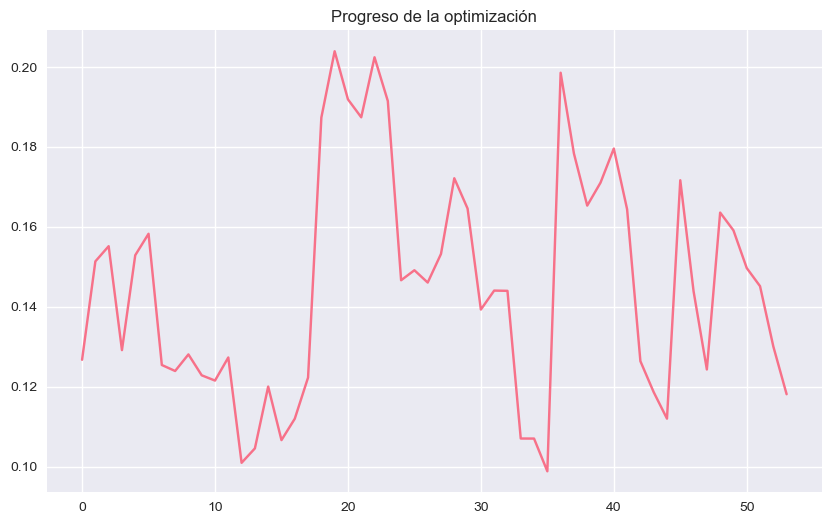

['../models/mejor_modelo.pkl']

In [13]:
# Mostrar comparación antes/después
print(f"Mejora en R²: {r2_score(y_test, y_pred) - results_df.iloc[0]['R²']:.4f}")

# Visualizar la optimización
results_df_cv = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(10,6))
plt.plot(results_df_cv['mean_test_score'])
plt.title('Progreso de la optimización')
plt.show()
joblib.dump(best_model, '../models/mejor_modelo.pkl')

## Análisis de Importancia de Características


Top 20 características más importantes:
                                     feature  importance
2                                       Area    0.500960
3                               Num. garages    0.032668
74   sector_Avenida República de El Salvador    0.029763
57                  sector_Av. de los Shyris    0.025054
136                        sector_La Kennedy    0.022492
68     sector_Avenida La Coruña & Valladolid    0.021998
154                         sector_Miravalle    0.020728
11                            ciudad_Cumbayá    0.017058
175                         sector_Sangolqui    0.015466
0                           Num. dormitorios    0.014329
1                                 Num. banos    0.014167
67              sector_Avenida Isla Floreana    0.011320
166                     sector_Ponceano Alto    0.011195
37                 sector_Av. 6 de Diciembre    0.010600
96                           sector_Conocoto    0.009706
33        sector_Av República de El Salvador   

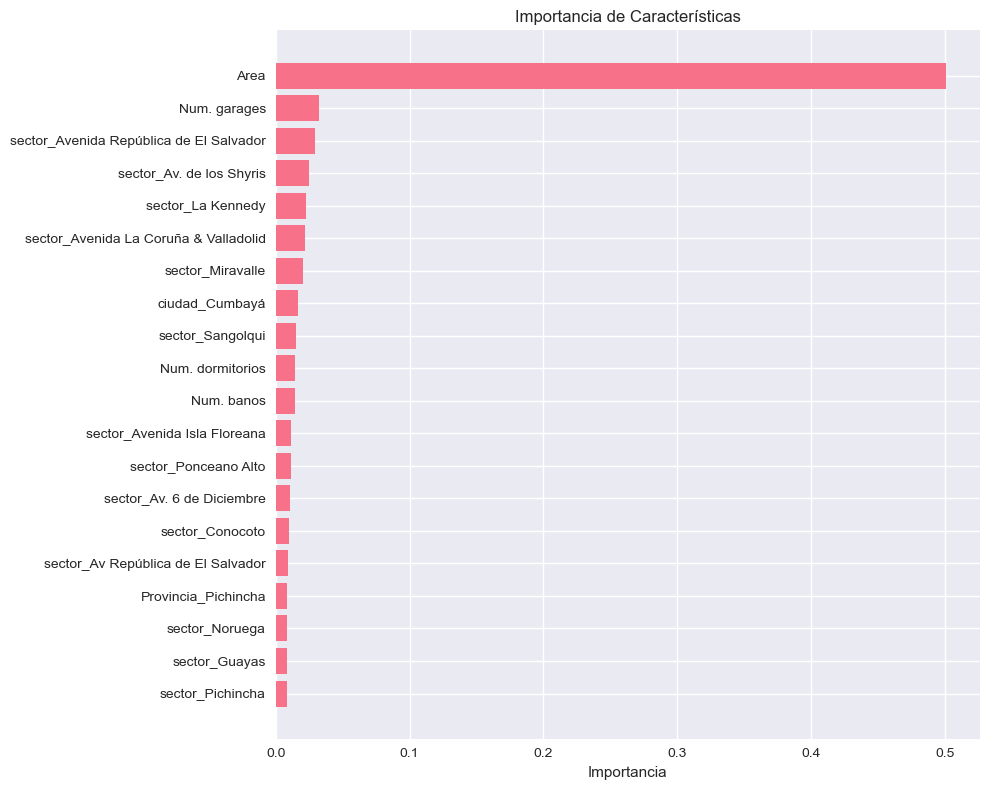

In [14]:
# Analiza y visualiza la importancia de características de un modelo de machine learning
if hasattr(best_model.named_steps['regressor'], 'feature_importances_'):
    # Obtener nombres de características después del preprocesamiento
    feature_names = (numeric_cols + 
                     list(best_model.named_steps['preprocessor']
                          .named_transformers_['cat']
                          .get_feature_names_out(categorical_cols)))
    
    importances = best_model.named_steps['regressor'].feature_importances_
    
    # Crear DataFrame y ordenar
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    # Mostrar top 20
    print("\nTop 20 características más importantes:")
    print(importance_df.head(20))
    
    # Visualizar
    plt.figure(figsize=(10, 8))
    plt.barh(importance_df.head(20)['feature'], importance_df.head(20)['importance'])
    plt.xlabel('Importancia')
    plt.title('Importancia de Características')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('../plots/feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()

## Guardar el Modelo

In [15]:
# Guardar el modelo
joblib.dump(best_model, '../models/rental_price_model.pkl')

# Guardar también los encoders y escaladores por separado (opcional)
model_artifacts = {
    'model': best_model,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols
}
joblib.dump(model_artifacts, '../models/model_artifacts.pkl')

print("Modelo guardado exitosamente!")

Modelo guardado exitosamente!
